## Challenge
Gunakan dataset publik apa saja (misalnya data CSV penjualan atau Titanic), lalu hitung rata-rata nilai pada kolom numerik berdasarkan kategori tertentu menggunakan metode ```.groupby()```.

## 1. Import Library

In [11]:
import pandas as pd
import numpy as np
"""
Membutuhkan Library Kagglehub dikarenakan kita menggunakan kernel/runtime google colab.
Oleh karena itu untuk bisa mengakses dataset dari platform kaggle kita harus
download datasetnya lewat library kagglehub.
"""
import kagglehub
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Download Dataset 

In [12]:
path = kagglehub.dataset_download("dansbecker/melbourne-housing-snapshot")
path

Using Colab cache for faster access to the 'melbourne-housing-snapshot' dataset.


'/kaggle/input/melbourne-housing-snapshot'

## 3. Load Dataset

In [13]:
df = pd.read_csv("/kaggle/input/melbourne-housing-snapshot/melb_data.csv")
df.head(10)

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,3/12/2016,2.5,3067.0,...,1.0,1.0,202.0,NaN,NaN,Yarra,-37.7996,144.9984,Northern Metropolitan,4019.0
1,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,4/02/2016,2.5,3067.0,...,1.0,0.0,156.0,79.0,1900.0,Yarra,-37.8079,144.9934,Northern Metropolitan,4019.0
2,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,4/03/2017,2.5,3067.0,...,2.0,0.0,134.0,150.0,1900.0,Yarra,-37.8093,144.9944,Northern Metropolitan,4019.0
3,Abbotsford,40 Federation La,3,h,850000.0,PI,Biggin,4/03/2017,2.5,3067.0,...,2.0,1.0,94.0,NaN,NaN,Yarra,-37.7969,144.9969,Northern Metropolitan,4019.0
4,Abbotsford,55a Park St,4,h,1600000.0,VB,Nelson,4/06/2016,2.5,3067.0,...,1.0,2.0,120.0,142.0,2014.0,Yarra,-37.8072,144.9941,Northern Metropolitan,4019.0
5,Abbotsford,129 Charles St,2,h,941000.0,S,Jellis,7/05/2016,2.5,3067.0,...,1.0,0.0,181.0,NaN,NaN,Yarra,-37.8041,144.9953,Northern Metropolitan,4019.0
6,Abbotsford,124 Yarra St,3,h,1876000.0,S,Nelson,7/05/2016,2.5,3067.0,...,2.0,0.0,245.0,210.0,1910.0,Yarra,-37.8024,144.9993,Northern Metropolitan,4019.0
7,Abbotsford,98 Charles St,2,h,1636000.0,S,Nelson,8/10/2016,2.5,3067.0,...,1.0,2.0,256.0,107.0,1890.0,Yarra,-37.8060,144.9954,Northern Metropolitan,4019.0
8,Abbotsford,6/241 Nicholson St,1,u,300000.0,S,Biggin,8/10/2016,2.5,3067.0,...,1.0,1.0,0.0,NaN,NaN,Yarra,-37.8008,144.9973,Northern Metropolitan,4019.0
9,Abbotsford,10 Valiant St,2,h,1097000.0,S,Biggin,8/10/2016,2.5,3067.0,...,1.0,2.0,220.0,75.0,1900.0,Yarra,-37.8010,144.9989,Northern Metropolitan,4019.0


## 4. Data Preprocessing

In [14]:
# Membuat data baru dengan mengcopy datanya guna
# untuk menjaga data aslinya.
df_new = df.copy()
df_new

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,3/12/2016,2.5,3067.0,...,1.0,1.0,202.0,NaN,NaN,Yarra,-37.79960,144.99840,Northern Metropolitan,4019.0
1,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,4/02/2016,2.5,3067.0,...,1.0,0.0,156.0,79.0,1900.0,Yarra,-37.80790,144.99340,Northern Metropolitan,4019.0
2,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,4/03/2017,2.5,3067.0,...,2.0,0.0,134.0,150.0,1900.0,Yarra,-37.80930,144.99440,Northern Metropolitan,4019.0
3,Abbotsford,40 Federation La,3,h,850000.0,PI,Biggin,4/03/2017,2.5,3067.0,...,2.0,1.0,94.0,NaN,NaN,Yarra,-37.79690,144.99690,Northern Metropolitan,4019.0
4,Abbotsford,55a Park St,4,h,1600000.0,VB,Nelson,4/06/2016,2.5,3067.0,...,1.0,2.0,120.0,142.0,2014.0,Yarra,-37.80720,144.99410,Northern Metropolitan,4019.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13575,Wheelers Hill,12 Strada Cr,4,h,1245000.0,S,Barry,26/08/2017,16.7,3150.0,...,2.0,2.0,652.0,NaN,1981.0,NaN,-37.90562,145.16761,South-Eastern Metropolitan,7392.0
13576,Williamstown,77 Merrett Dr,3,h,1031000.0,SP,Williams,26/08/2017,6.8,3016.0,...,2.0,2.0,333.0,133.0,1995.0,NaN,-37.85927,144.87904,Western Metropolitan,6380.0
13577,Williamstown,83 Power St,3,h,1170000.0,S,Raine,26/08/2017,6.8,3016.0,...,2.0,4.0,436.0,NaN,1997.0,NaN,-37.85274,144.88738,Western Metropolitan,6380.0
13578,Williamstown,96 Verdon St,4,h,2500000.0,PI,Sweeney,26/08/2017,6.8,3016.0,...,1.0,5.0,866.0,157.0,1920.0,NaN,-37.85908,144.89299,Western Metropolitan,6380.0


### 4.1 Detect And Handle Missing Value Data

#### 📊 Panduan Cek Data Kosong (`NaN`) di Pandas

##### 1. Menghitung Jumlah Nilai Kosong per Kolom

Gunakan kode ini jika Anda ingin mengetahui berapa banyak total baris yang kosong di setiap kolom:

```python
df_clean.isna().sum()
```

> **Catatan:** Jangan gunakan `df_clean[...]` atau `.any(axis=1)` di bagian depan agar hasilnya menampilkan ringkasan per kolom secara spesifik.


##### 2. Menampilkan Baris yang Memiliki Nilai Kosong

Gunakan kode ini jika Anda ingin melihat baris data mana saja yang mengandung setidaknya satu nilai kosong:

```python
df_clean[df_clean.isna().any(axis=1)]
```

> **Catatan:** Jangan gunakan `.sum()` di akhir perintah agar bentuk output tetap berupa DataFrame baris data utuh, bukan angka total matematika.

---

#### 🔍 Bedah Kesalahan: Mengapa Kode Sebelumnya Keliru?

Pernahkah Anda menulis kode seperti ini dan mendapati hasil angka yang aneh (seperti total umur, bukan jumlah data kosong)?

```python
df_clean[df_clean.isna().any(axis=1)].sum()
```

Berikut adalah bedah alur logika kenapa hal tersebut bisa terjadi:

 **1. Filtering (Penyaringan)**
* **Kode:** `df_clean.isna().any(axis=1)`
* **Fungsi:** Menyaring dan mendeteksi baris mana saja yang memiliki minimal satu kotak kosong (`NaN`). Baris yang bersih akan disingkirkan.


 **2. Extraction (Pengambilan)**
* **Kode:** `df_clean[...]`
* **Fungsi:** Mengambil baris-baris yang terjaring tadi secara utuh bersama seluruh kolom angkanya (misalnya kolom umur dan tarif), meskipun kolom-kolom tersebut sebenarnya tidak kosong.


 **3. Calculation / Penghitungan**
* **Kode:** `.sum()`
* **Fungsi:** Menjumlahkan secara matematis seluruh angka dari kolom-kolom pada baris yang ditarik. Inilah alasan Anda mendapatkan total nilai angka (seperti total akumulasi umur), alih-alih jumlah kotak yang kosong.



---

In [15]:
# Check isi dari NA(Not Available) semua kolom.
df_new.isna().sum()

,0
Suburb,0
Address,0
Rooms,0
Type,0
Price,0
Method,0
SellerG,0
Date,0
Distance,0
Postcode,0


In [16]:
# Drop(Remove) data hilang dari kolom data embarked.
df_clean = df_new.dropna(subset=["Car", "BuildingArea", "YearBuilt", "CouncilArea"]).reset_index(drop=True)
# Untuk memastikan kolomnya udah bersih dari data nilai hilang(missing value).
df_clean.isna().sum()

,0
Suburb,0
Address,0
Rooms,0
Type,0
Price,0
Method,0
SellerG,0
Date,0
Distance,0
Postcode,0


### 4.2 Detect And Handle Duplicates Data

In [17]:
# Check data duplikat
df_clean.duplicated().sum()

np.int64(0)

### 4.3 Handle And Detect Data Outlier


In [18]:
df_detect_outlier = df_clean.copy()

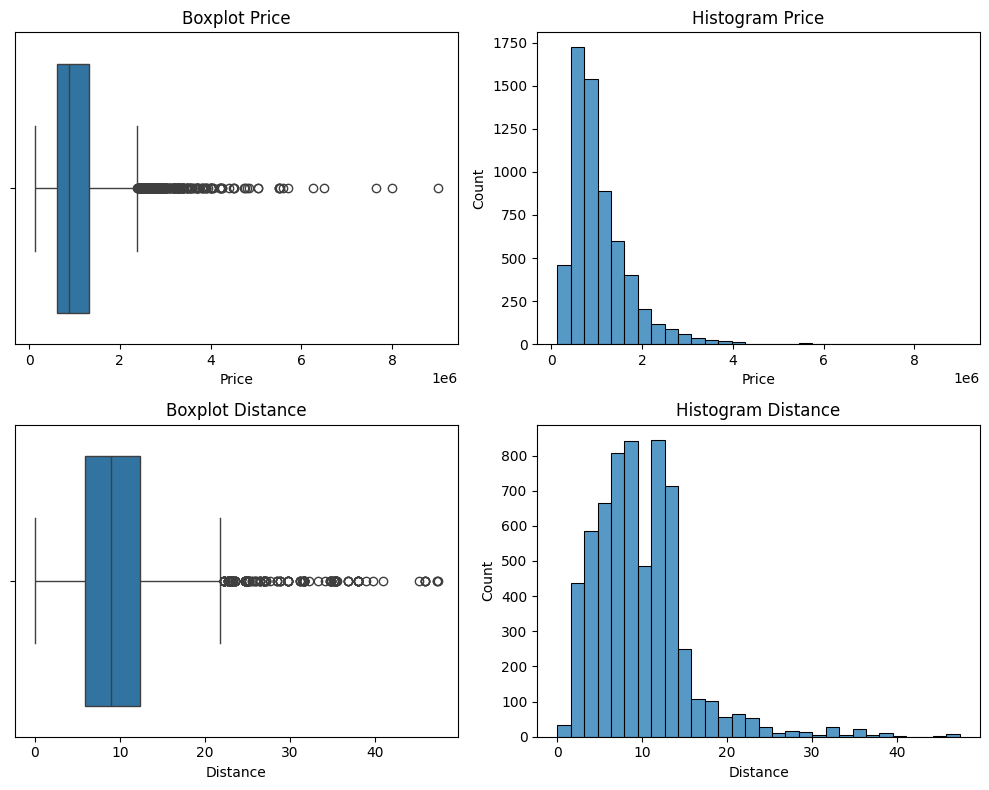

In [19]:
fig, ((axs0, axs1), (axs2, axs3)) = plt.subplots(2, 2, figsize=(10, 8))
sns.boxplot(x=df_detect_outlier["Price"], ax=axs0)
axs0.set_title("Boxplot Price")
sns.histplot(df_detect_outlier["Price"], bins=30, ax=axs1)
axs1.set_title("Histogram Price")

sns.boxplot(x=df_detect_outlier["Distance"], ax=axs2)
axs2.set_title("Boxplot Distance")
sns.histplot(df_detect_outlier["Distance"], bins=30, ax=axs3)
axs3.set_title("Histogram Distance")
plt.tight_layout()
plt.show()

In [23]:
Q1 = df_detect_outlier["Price"].quantile(0.25)
Q3 = df_detect_outlier["Price"].quantile(0.75)
IQR = Q3 - Q1
batas_bawah = Q1 - 1.5 * IQR
batas_atas = Q3 + 1.5 * IQR

outlier_mask = (df_detect_outlier["Price"] < batas_bawah) | (df_detect_outlier["Price"] > batas_atas)
print(f"Batas: [{batas_bawah:.1f}, {batas_atas:.1f}]")
print(f"Jumlah outlier: {outlier_mask.sum()}")
df_detect_outlier[outlier_mask]

Batas: [-437500.0, 2382500.0]
Jumlah outlier: 288


,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
50,Albert Park,112 Beaconsfield Pde,3,h,2850000.0,PI,Buxton,4/03/2017,3.3,3206.0,...,2.0,0.0,211.0,198.0,1890.0,Port Phillip,-37.84810,144.94990,Southern Metropolitan,3280.0
57,Albert Park,2 Dundas Pl,3,h,2615000.0,S,Cayzer,10/12/2016,3.3,3206.0,...,2.0,1.0,177.0,181.0,1880.0,Port Phillip,-37.84150,144.95850,Southern Metropolitan,3280.0
62,Albert Park,97 Page St,3,h,3010000.0,S,Greg,18/03/2017,3.3,3206.0,...,2.0,0.0,147.0,146.0,1890.0,Port Phillip,-37.84730,144.95510,Southern Metropolitan,3280.0
63,Albert Park,55 Withers St,4,h,2800000.0,VB,Cayzer,18/06/2016,3.3,3206.0,...,3.0,1.0,327.0,254.0,1910.0,Port Phillip,-37.84670,144.94750,Southern Metropolitan,3280.0
67,Albert Park,115 Page St,4,h,4735000.0,S,Marshall,25/02/2017,3.3,3206.0,...,2.0,1.0,330.0,207.0,1910.0,Port Phillip,-37.84770,144.95580,Southern Metropolitan,3280.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6066,Camberwell,6 Regent St,4,h,2500000.0,VB,Fletchers,29/07/2017,7.7,3124.0,...,2.0,3.0,947.0,225.0,1930.0,Boroondara,-37.84403,145.09545,Southern Metropolitan,8920.0
6119,Ivanhoe,25 Fairy St,4,h,2530000.0,VB,Miles,29/07/2017,7.8,3079.0,...,2.0,0.0,637.0,306.0,1936.0,Banyule,-37.77671,145.04005,Eastern Metropolitan,5549.0
6123,Kew,11 Raheen Dr,4,h,3015000.0,S,Jellis,29/07/2017,5.4,3101.0,...,2.0,2.0,813.0,276.0,1970.0,Boroondara,-37.80437,145.01725,Southern Metropolitan,10331.0
6141,Mulgrave,35 Bevis St,3,h,9000000.0,PI,Hall,29/07/2017,18.8,3170.0,...,1.0,1.0,744.0,117.0,1960.0,Monash,-37.93168,145.16126,South-Eastern Metropolitan,7113.0
